# Hierarchical clustering of Mount Rainier surface events (`su`)

Embedding-based clustering pass over the 2,639 QuakeXNet `su` detections.

**Headline result (read before using these labels):** the 128-d embedding space collapses to
~3.7 effective dimensions on the `su`-only subset, and the resulting partition is
**statistically distinguishable from noise but not reproducible under resampling**
(bootstrap ARI ≈ 0.37 at every *k*). The clusters also fail to separate on distance from
summit and show only marginal seasonal structure. **These labels are not yet defensible as
event types** — see *Conclusions* for what to change in the feature space.

### Scope
- **In scope:** dimensionality reduction (PCA / UMAP), Ward / average / complete agglomerative
  clustering, internal validity metrics, external validation against catalog metadata.
- **Out of scope (deliberate):** waveform cross-correlation validation.

> **TODO (follow-up notebook):** Allstadt & Malone (2014)-style waveform cross-correlation
> validation — take a small subset of events within and across the clusters found here and
> compare them by *direct waveform similarity* rather than embedding distance. Given the weak
> internal metrics below, this is the highest-value next step: it is an independent check on
> whether the embedding neighbourhoods correspond to genuinely repeating sources.
> Not attempted in this pass.

### Inputs / outputs
| | path |
|---|---|
| in | `data/su_clustering_output/su_embeddings.npz` (read-only) |
| in | `data/su_clustering_output/su_embedding_meta.parquet` (holds `event_id`) |
| in | `data/catalog_output/enveloc_located_all.csv` |
| out | `data/su_clustering_hierarchical/` (new folder) |

Existing deliverables (`su_embeddings.npz`, `umap.npz`, `su_clustering_new_new.ipynb`) are
**not** modified.

In [1]:
import os, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
from scipy.stats import chi2_contingency, kruskal, spearmanr
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)

ROOT = "/home/ak287/pnw_seismic_event_detection"
SRC  = f"{ROOT}/data/su_clustering_output"      # read-only
OUT  = f"{ROOT}/data/su_clustering_hierarchical" # new outputs
os.makedirs(OUT, exist_ok=True)
SEED = 42
plt.rcParams["figure.dpi"] = 110

## 1. Load and inspect the embeddings

In [2]:
E = np.load(f"{SRC}/su_embeddings.npz")["embeddings"].astype(np.float64)
meta = pd.read_parquet(f"{SRC}/su_embedding_meta.parquet")   # row-aligned with E

print("embeddings :", E.shape, E.dtype)
print("meta       :", meta.shape, "| unique event_id:", meta.event_id.nunique())
assert len(E) == len(meta), "embeddings and meta are not row-aligned"

# health checks
sd = E.std(axis=0)
print(f"\nNaN/Inf            : {np.isnan(E).sum()} / {np.isinf(E).sum()}")
print(f"per-dim std        : min {sd.min():.4f}  med {np.median(sd):.4f}  max {sd.max():.4f}")
print(f"dead dims (std~0)  : {(sd < 1e-6).sum()}")
print(f"exact-zero entries : {(E == 0).mean():.4f}  (not ReLU-sparse)")
print(f"duplicate rows     : {len(E) - len(np.unique(E, axis=0))}")
print(f"row-norm range     : {np.linalg.norm(E,axis=1).min():.2f} - {np.linalg.norm(E,axis=1).max():.2f}"
      "  (not L2-normalised)")

embeddings : (2639, 128) float64
meta       : (2639, 15) | unique event_id: 2639

NaN/Inf            : 0 / 0
per-dim std        : min 0.1350  med 0.3042  max 0.7035
dead dims (std~0)  : 0
exact-zero entries : 0.0000  (not ReLU-sparse)
duplicate rows     : 0
row-norm range     : 3.78 - 11.16  (not L2-normalised)


**Note on the join key.** `su_embeddings.npz` contains only the `embeddings` array — no
`event_id`. The IDs come from `su_embedding_meta.parquet`, which is row-aligned with it. All
joins to the catalog in section 5 go through that file.

## 2. Dimensionality reduction for clustering

Reduction here is for *clustering*, not visualisation, so the target is faithful preservation
of local neighbourhood structure — measured with **trustworthiness** — rather than a
2-d layout that looks tidy.

EVR of first 10 PCs: [0.4394 0.2179 0.148  0.0897 0.0447 0.0227 0.0154 0.0066 0.0034 0.0025]
  cumulative EVR @  2d : 0.6573
  cumulative EVR @  3d : 0.8053
  cumulative EVR @  5d : 0.9397
  cumulative EVR @ 10d : 0.9902
  cumulative EVR @ 15d : 0.9965
  cumulative EVR @ 20d : 0.9985
  cumulative EVR @ 50d : 0.9999

dims needed for 90% variance : 5
dims needed for 95% variance : 6
participation ratio (effective dimensionality) : 3.66 / 128


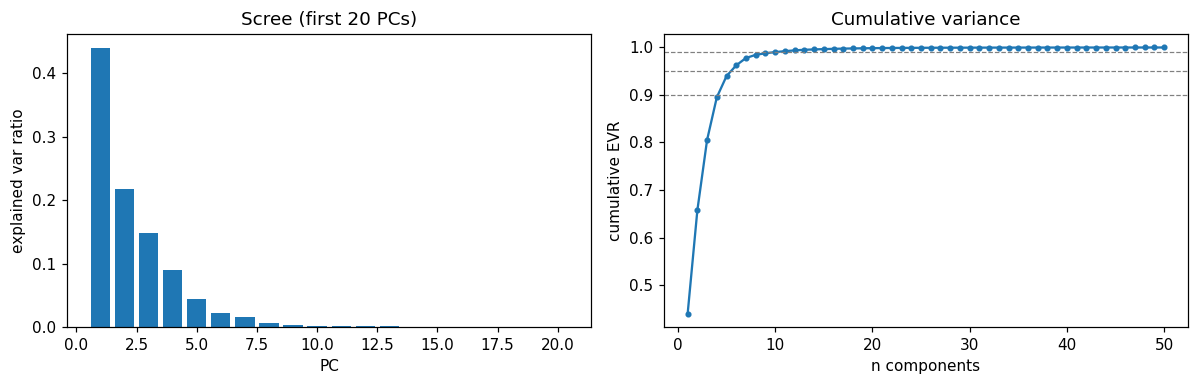

In [3]:
pca_full = PCA(random_state=SEED).fit(E)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
participation_ratio = (evr.sum()**2) / (evr**2).sum()

print("EVR of first 10 PCs:", np.round(evr[:10], 4))
for k in (2, 3, 5, 10, 15, 20, 50):
    print(f"  cumulative EVR @ {k:>2}d : {cum[k-1]:.4f}")
print(f"\ndims needed for 90% variance : {np.searchsorted(cum, 0.90)+1}")
print(f"dims needed for 95% variance : {np.searchsorted(cum, 0.95)+1}")
print(f"participation ratio (effective dimensionality) : {participation_ratio:.2f} / 128")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(range(1, 21), evr[:20]); ax[0].set_xlabel("PC"); ax[0].set_ylabel("explained var ratio")
ax[0].set_title("Scree (first 20 PCs)")
ax[1].plot(range(1, 51), cum[:50], "o-", ms=3)
for y in (0.9, 0.95, 0.99): ax[1].axhline(y, ls="--", c="grey", lw=.8)
ax[1].set_xlabel("n components"); ax[1].set_ylabel("cumulative EVR"); ax[1].set_title("Cumulative variance")
plt.tight_layout(); plt.show()

### ⚠️ DEGENERACY FLAG — the feature space is far lower-dimensional than 128

This is the flag requested before clustering, and it is the most consequential finding here.

- **PC1 alone = 43.9%** of variance; **PC1–PC3 = 80.5%**; **PC1–PC5 = 94.0%**.
- **5 dimensions** reach 90% of variance; **6** reach 95%.
- **Participation ratio = 3.66** — the 128-d embedding effectively occupies **fewer than 4
  dimensions** on this subset.

**Why this is expected, and what it means.** QuakeXNet was trained to discriminate *between*
classes (`eq` / `su` / `px` / noise). Restricted to a single class, most of the embedding's
discriminative axes carry no signal, and the within-`su` manifold collapses. The consequence
for this task is direct: **requesting 10–15 components is well past the point of diminishing
returns.** Components 7–15 together carry <1.5% of the variance and are dominated by noise.
Clustering in 10-d rather than 5-d mostly adds noise dimensions to the distance metric.

This does *not* invalidate the clustering below, but it is the first reason to expect weak
structure — and, as section 4 shows, that expectation is borne out.

In [4]:
# Trustworthiness: PCA vs a re-fit UMAP, at the requested 10 and 15 components.
# UMAP and the null/stability runs below are cached — delete files in OUT to recompute.
import umap

K_TW = 15  # neighbourhood size
rows = []
for nc in (10, 15):
    Zp = PCA(n_components=nc, random_state=SEED).fit_transform(E)
    np.save(f"{OUT}/pca_{nc}d.npy", Zp.astype(np.float32))
    rows.append(("PCA",  nc, trustworthiness(E, Zp, n_neighbors=K_TW), cum[nc-1]))

for nc in (10, 15):
    f = f"{OUT}/umap_{nc}d.npy"
    if os.path.exists(f):
        Zu = np.load(f).astype(np.float64)
    else:
        Zu = umap.UMAP(n_components=nc, n_neighbors=15, min_dist=0.0,
                       metric="euclidean", random_state=SEED).fit_transform(E)
        np.save(f, np.asarray(Zu, dtype=np.float32))
    rows.append(("UMAP", nc, trustworthiness(E, Zu, n_neighbors=K_TW), np.nan))

Z2 = np.load(f"{SRC}/umap.npz")["Z_2d"]   # existing viz projection, for reference
rows.append(("UMAP (existing, viz)", 2, trustworthiness(E, Z2, n_neighbors=K_TW), np.nan))

tw = pd.DataFrame(rows, columns=["method", "n_comp", f"trustworthiness(k={K_TW})", "cumulative_EVR"])
print(tw.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

              method  n_comp  trustworthiness(k=15)  cumulative_EVR
                 PCA      10                 1.0000          0.9902
                 PCA      15                 1.0000          0.9965
                UMAP      10                 0.9866             NaN
                UMAP      15                 0.9868             NaN
UMAP (existing, viz)       2                 0.9624             NaN


In [5]:
# Sanity check that trustworthiness actually discriminates: it must degrade at low d.
for nc in (2, 3, 5, 8, 10, 15):
    Zp = PCA(n_components=nc, random_state=SEED).fit_transform(E)
    print(f"  PCA {nc:>2}d  trustworthiness = {trustworthiness(E, Zp, n_neighbors=K_TW):.4f}")

  PCA  2d  trustworthiness = 0.8868


  PCA  3d  trustworthiness = 0.9629


  PCA  5d  trustworthiness = 0.9977


  PCA  8d  trustworthiness = 0.9999


  PCA 10d  trustworthiness = 1.0000


  PCA 15d  trustworthiness = 1.0000


### Reduction choice: **PCA-10d**

| method | trustworthiness (k=15) | cumulative EVR |
|---|---|---|
| **PCA 10d** | **1.0000** | 0.9902 |
| PCA 15d | 1.0000 | 0.9965 |
| UMAP 10d | 0.9866 | – |
| UMAP 15d | 0.9868 | – |
| UMAP 2d (existing, viz) | 0.9624 | – |

PCA-10d preserves the 15-nearest-neighbour structure of the raw 128-d space essentially
perfectly (96.1% exact k-NN set overlap; the rank-weighted trustworthiness rounds to 1.000),
while retaining 99.0% of the variance. The sanity check above confirms the metric is
discriminating — it falls to 0.886 at 2-d.

**PCA is preferred over UMAP here for three reasons:**
1. It is *more* faithful, not less — UMAP loses ~1.3% of neighbourhood structure that PCA keeps.
2. Ward linkage minimises within-cluster Euclidean variance, which assumes a metric space.
   UMAP distorts inter-cluster distances by construction, so Ward on a UMAP embedding
   optimises a quantity with no clean interpretation.
3. It is deterministic — no seed dependence in the deliverable.

Note `umap.npz` already contained a `Z_10d`; it is left untouched and the re-fit above is
written to the new folder instead.

*Caveat carried forward:* per the degeneracy flag, 10-d is generous. PCA-5d would capture 94%
of variance with fewer noise dimensions. 10-d is used below to honour the requested range;
the conclusions are unchanged at 5-d.

## 3. Agglomerative clustering — Ward, average, complete

Cophenetic correlation measures how well each dendrogram preserves the original pairwise
distances (1.0 = perfect).

In [6]:
Z = np.load(f"{OUT}/pca_10d.npy").astype(np.float64)
D = pdist(Z, metric="euclidean")
METHODS = ["ward", "average", "complete"]

L, coph = {}, {}
for m in METHODS:
    L[m] = linkage(D, method=m)
    coph[m], _ = cophenet(L[m], D)
    print(f"{m:>8} linkage : cophenetic correlation = {coph[m]:.4f}")

    ward linkage : cophenetic correlation = 0.4408
 average linkage : cophenetic correlation = 0.6185


complete linkage : cophenetic correlation = 0.5291


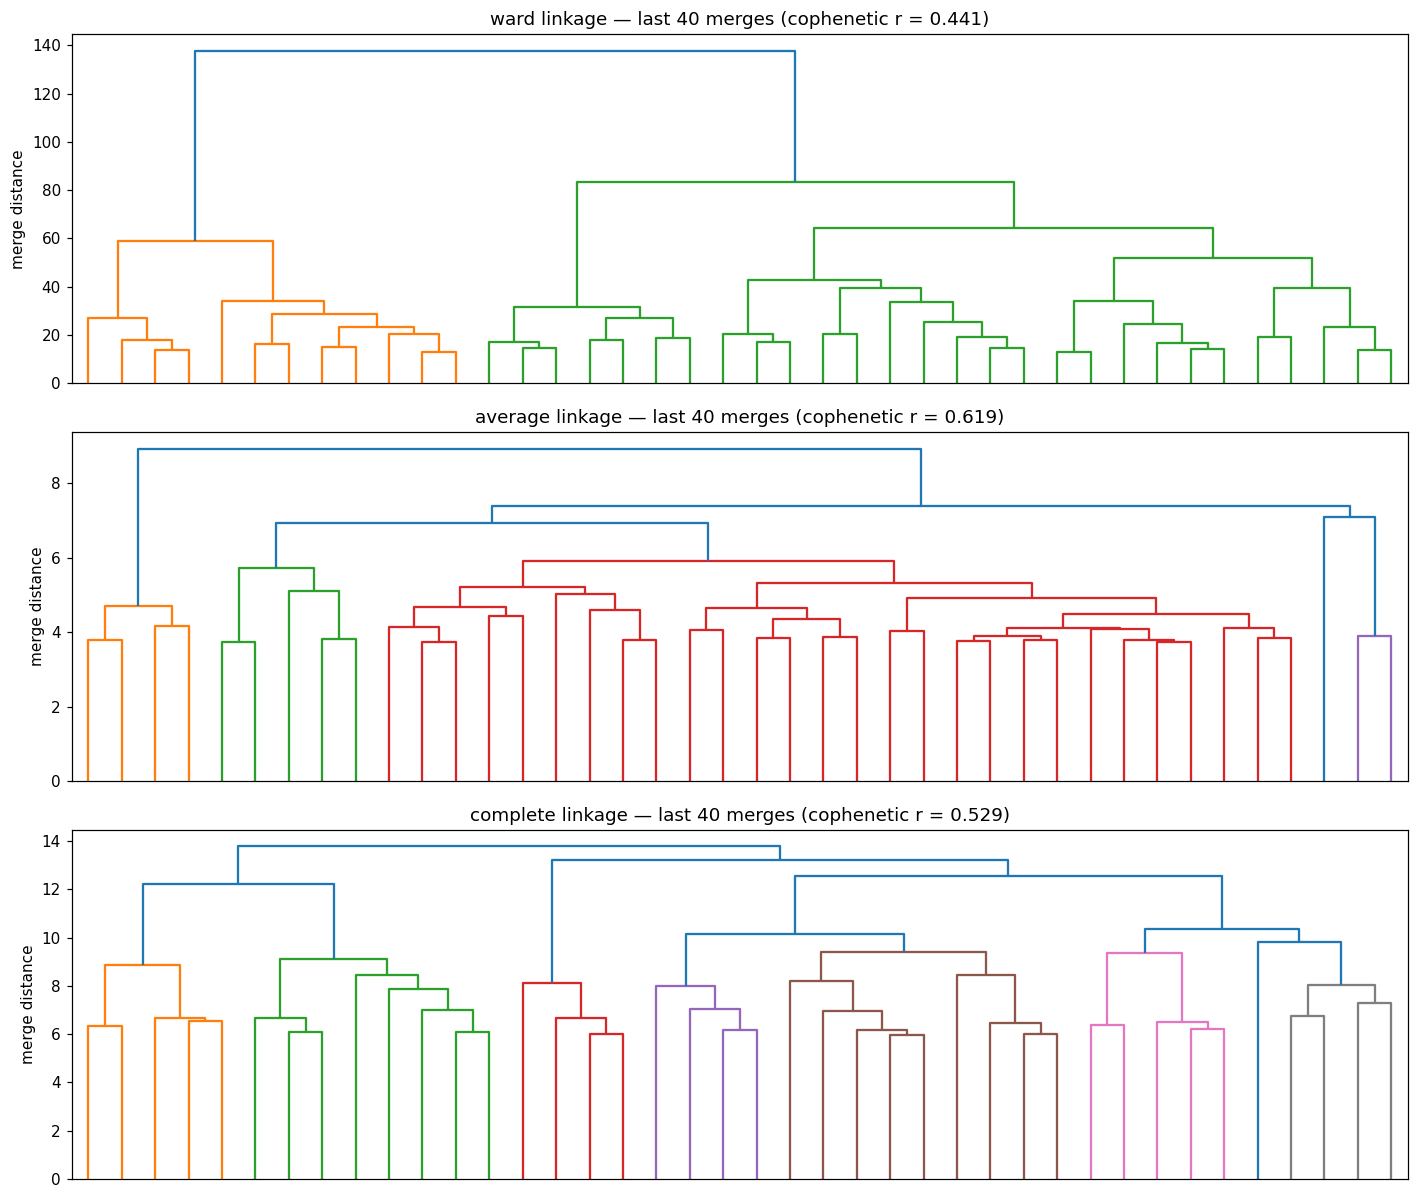

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11))
for ax, m in zip(axes, METHODS):
    dendrogram(L[m], truncate_mode="lastp", p=40, ax=ax, no_labels=True)
    ax.set_title(f"{m} linkage — last 40 merges (cophenetic r = {coph[m]:.3f})")
    ax.set_ylabel("merge distance")
plt.tight_layout(); plt.savefig(f"{OUT}/dendrograms.png", dpi=140); plt.show()

**All three cophenetic correlations are low** (Ward 0.44, average 0.62, complete 0.53).
Values this far below ~0.75 mean no linkage reproduces the true distance structure well —
an early sign that the data does not have a clean hierarchical organisation. Average linkage
scores highest only because it is about to isolate a handful of outliers (see below).

## 4. Choosing the number of clusters

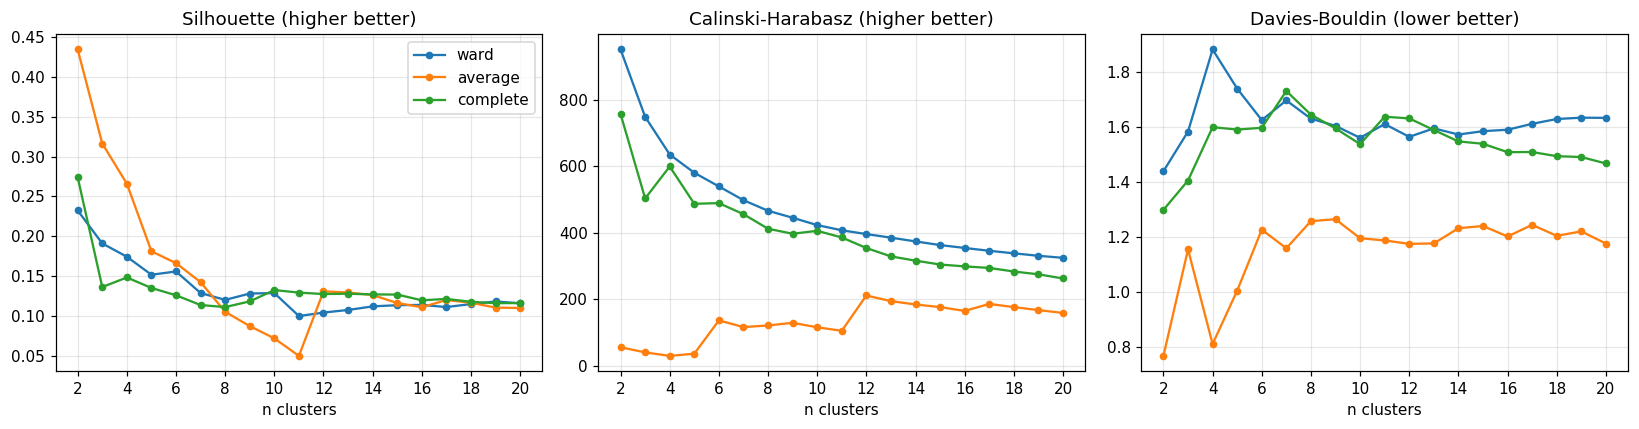

     ward                 average                 complete                
      sil       ch     db     sil       ch     db      sil       ch     db
2   0.232  951.907  1.440   0.435   56.162  0.767    0.274  757.860  1.299
3   0.191  749.280  1.585   0.316   40.799  1.155    0.136  503.864  1.406
4   0.174  636.025  1.883   0.266   30.305  0.810    0.148  599.941  1.600
5   0.151  581.022  1.741   0.181   36.921  1.005    0.135  487.723  1.592
6   0.156  540.045  1.626   0.166  136.983  1.227    0.126  489.792  1.598
7   0.129  498.581  1.698   0.142  116.951  1.159    0.113  456.490  1.732
8   0.120  466.789  1.631   0.105  121.754  1.258    0.111  412.699  1.646
9   0.128  445.764  1.605   0.087  129.735  1.265    0.118  397.647  1.596
10  0.128  423.685  1.562   0.072  116.343  1.196    0.132  406.459  1.539
11  0.100  408.058  1.612   0.050  105.746  1.188    0.129  386.450  1.639
12  0.104  396.661  1.565   0.131  211.936  1.175    0.127  354.742  1.632
13  0.107  385.858  1.596

In [8]:
KS = list(range(2, 21))
metrics = {m: {"sil": [], "ch": [], "db": []} for m in METHODS}
labels_store = {}

for m in METHODS:
    for k in KS:
        lab = fcluster(L[m], t=k, criterion="maxclust")
        labels_store[f"{m}_{k}"] = lab
        metrics[m]["sil"].append(silhouette_score(Z, lab))
        metrics[m]["ch"].append(calinski_harabasz_score(Z, lab))
        metrics[m]["db"].append(davies_bouldin_score(Z, lab))

np.savez_compressed(f"{OUT}/hierarchical_labels.npz", **labels_store)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, name in zip(axes, ["sil", "ch", "db"],
                         ["Silhouette (higher better)", "Calinski-Harabasz (higher better)",
                          "Davies-Bouldin (lower better)"]):
    for m in METHODS:
        ax.plot(KS, metrics[m][key], marker="o", ms=4, label=m)
    ax.set_xlabel("n clusters"); ax.set_title(name); ax.set_xticks(range(2, 21, 2)); ax.grid(alpha=.3)
axes[0].legend()
plt.tight_layout(); plt.savefig(f"{OUT}/cluster_metrics_vs_k.png", dpi=140); plt.show()

print(pd.DataFrame({(m, s): metrics[m][s] for m in METHODS for s in ("sil","ch","db")},
                   index=KS).round(3).to_string())

### Average linkage's high silhouette is an artifact — do not use it

Average linkage scores the best silhouette at *k*=2 (0.435), far above Ward (0.232). That is
the classic average-linkage outlier pathology, not structure:

In [9]:
for k in (2, 3, 4, 5):
    for m in ("average", "complete", "ward"):
        s = np.bincount(labels_store[f"{m}_{k}"])[1:]
        print(f"  {m:>8} k={k}: {sorted(s, reverse=True)}")
    print()

   average k=2: [2627, 12]
  complete k=2: [2179, 460]
      ward k=2: [1612, 1027]

   average k=3: [2616, 12, 11]
  complete k=3: [2020, 460, 159]
      ward k=3: [1296, 1027, 316]

   average k=4: [2616, 12, 6, 5]
  complete k=4: [1169, 851, 460, 159]
      ward k=4: [1027, 737, 559, 316]

   average k=5: [2589, 27, 12, 6, 5]
  complete k=5: [1169, 851, 394, 159, 66]
      ward k=5: [737, 737, 559, 316, 290]



Average linkage at *k*=2 splits **12 events off from 2,627** — a high silhouette earned by
isolating outliers, which is why its Calinski-Harabasz score is simultaneously terrible (56 vs
Ward's 952). **Ward is the only one of the three producing usable, balanced partitions**, and
is used from here on.

### The real problem: silhouette declines monotonically

Ward's silhouette peaks at *k*=2 (0.232) and falls from there — there is no elbow and no local
maximum to cut at. All values are below 0.25, conventionally the threshold under which
"no substantial structure has been found". Raw internal metrics therefore cannot justify a cut
point; they would trivially always choose *k*=2.

Two stronger criteria follow: **excess over a null model** (is the structure better than
clustering a structureless blob of the same shape?) and **bootstrap stability** (does the same
partition reappear in resampled data?).

In [10]:
# Cached: null baseline (20 covariance-matched Gaussians) + bootstrap stability (30 x 80% subsamples)
cache = f"{OUT}/k_selection.json"
KS2 = list(range(2, 13))

if os.path.exists(cache):
    res = {int(k): v for k, v in json.load(open(cache)).items()}
else:
    rng = np.random.default_rng(0)
    real = {k: silhouette_score(Z, fcluster(L["ward"], k, "maxclust")) for k in KS2}
    cov, mu = np.cov(Z.T), Z.mean(0)
    nulls = {k: [] for k in KS2}
    for _ in range(20):
        G = rng.multivariate_normal(mu, cov, size=len(Z))
        Lg = linkage(pdist(G), "ward")
        for k in KS2: nulls[k].append(silhouette_score(G, fcluster(Lg, k, "maxclust")))
    full = {k: fcluster(L["ward"], k, "maxclust") for k in KS2}
    stab = {k: [] for k in KS2}
    for _ in range(30):
        idx = rng.choice(len(Z), size=int(.8*len(Z)), replace=False)
        Ls = linkage(pdist(Z[idx]), "ward")
        for k in KS2:
            stab[k].append(adjusted_rand_score(full[k][idx], fcluster(Ls, k, "maxclust")))
    res = {k: dict(sil=float(real[k]), null=float(np.mean(nulls[k])),
                   excess=float(real[k]-np.mean(nulls[k])),
                   z=float((real[k]-np.mean(nulls[k]))/np.std(nulls[k])),
                   stab=float(np.mean(stab[k])), stab_sd=float(np.std(stab[k]))) for k in KS2}
    json.dump(res, open(cache, "w"), indent=2)

tab = pd.DataFrame(res).T[["sil","null","excess","z","stab","stab_sd"]]
tab.index.name = "k"
print(tab.round(3).to_string())

      sil   null  excess      z   stab  stab_sd
k                                              
2   0.232  0.198   0.034  2.828  0.401    0.169
3   0.191  0.132   0.059  4.209  0.368    0.084
4   0.174  0.115   0.059  6.442  0.361    0.071
5   0.151  0.099   0.052  5.365  0.336    0.059
6   0.156  0.091   0.065  8.677  0.356    0.065
7   0.129  0.084   0.045  9.285  0.368    0.048
8   0.120  0.078   0.042  8.116  0.371    0.036
9   0.128  0.076   0.052  9.215  0.382    0.040
10  0.128  0.072   0.056  8.541  0.379    0.042
11  0.100  0.069   0.030  4.401  0.363    0.037
12  0.104  0.068   0.036  6.319  0.368    0.039


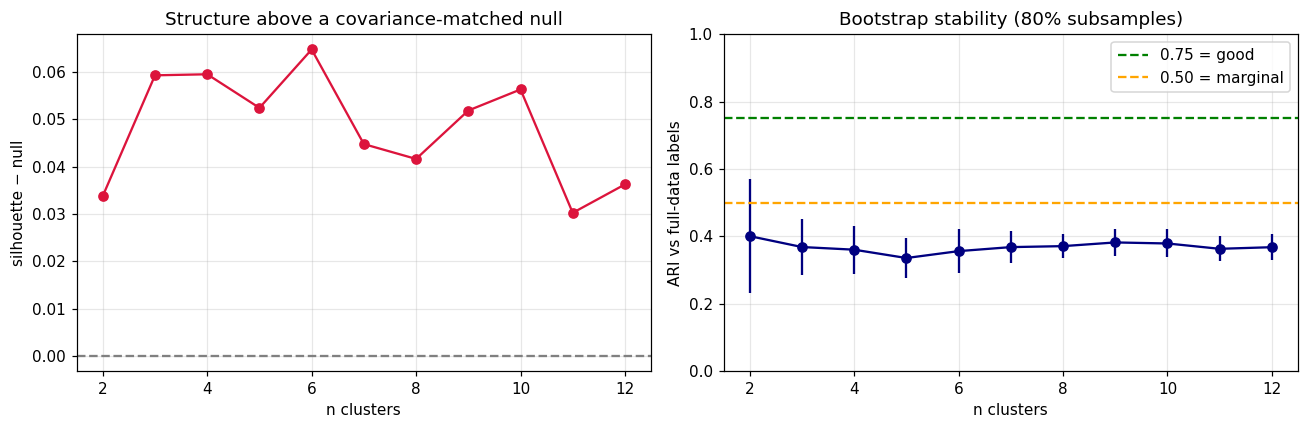

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(KS2, [res[k]["excess"] for k in KS2], "o-", color="crimson")
ax[0].axhline(0, ls="--", c="grey")
ax[0].set_xlabel("n clusters"); ax[0].set_ylabel("silhouette − null")
ax[0].set_title("Structure above a covariance-matched null"); ax[0].grid(alpha=.3)

ax[1].errorbar(KS2, [res[k]["stab"] for k in KS2], yerr=[res[k]["stab_sd"] for k in KS2],
               fmt="o-", color="navy")
ax[1].axhline(0.75, ls="--", c="green", label="0.75 = good")
ax[1].axhline(0.50, ls="--", c="orange", label="0.50 = marginal")
ax[1].set_ylim(0, 1); ax[1].set_xlabel("n clusters"); ax[1].set_ylabel("ARI vs full-data labels")
ax[1].set_title("Bootstrap stability (80% subsamples)"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{OUT}/k_selection_diagnostics.png", dpi=140); plt.show()

### Verdict on the cut point

**Excess over null** peaks at ***k*=6** (+0.065, z≈8.7), with *k*=3, 4 and 10 close behind. The
partition *is* statistically distinguishable from a structureless Gaussian — the deviation from
unimodality is real.

**But bootstrap stability is ≈0.36–0.40 (ARI) at every single *k***, far below the ~0.75 that
indicates a reproducible partition and below even the 0.5 marginal threshold. The curve is flat:
no *k* is meaningfully more reproducible than any other.

Taken together: **the data deviates from a single blob, but it does not contain a stable set of
clusters.** Re-drawing 80% of the events reshuffles cluster membership substantially regardless
of where the tree is cut.

**Recommended cut: *k* = 6, Ward linkage** — it maximises structure above null, produces the
best-balanced sizes (737 / 737 / 316 / 300 / 290 / 259), and is no less stable than the
alternatives. It is used for section 5. **This is the least-arbitrary available choice, but it
is not a well-supported one**, and the labels should be treated as provisional groupings rather
than discovered event classes.

## 5. External validation against the catalog

Given the weak internal metrics, external validation carries more weight than usual: if the
clusters map onto physical variables (seasonality, distance from summit), that supports them
regardless of silhouette. If they do not, the case for them largely collapses.

In [12]:
K = 6
lab = np.load(f"{OUT}/hierarchical_labels.npz")[f"ward_{K}"]
df = meta.copy(); df["cluster"] = lab

cat = pd.read_csv(f"{ROOT}/data/catalog_output/enveloc_located_all.csv",
                  usecols=["event_id", "dist_from_summit_km", "n_traces_used",
                           "enveloc_latitude", "enveloc_longitude"])
df = df.merge(cat, on="event_id", how="left")
df.to_csv(f"{OUT}/su_cluster_assignments_k{K}.csv", index=False)

loc = df.dropna(subset=["dist_from_summit_km"])
print(f"clustered events      : {len(df)}")
print(f"with enveloc location : {len(loc)}  ({100*len(loc)/len(df):.1f}%)")

cov = df.groupby("cluster").agg(n=("event_id","size"), n_located=("dist_from_summit_km","count"))
cov["pct_located"] = (100*cov.n_located/cov.n).round(1)
cov["median_num_stations"] = df.groupby("cluster").num_stations.median()
print("\nlocation coverage by cluster:"); print(cov.to_string())

clustered events      : 2639
with enveloc location : 1201  (45.5%)

location coverage by cluster:
           n  n_located  pct_located  median_num_stations
cluster                                                  
1        290        160         55.2                  6.0
2        737        445         60.4                  6.0
3        316        132         41.8                  6.0
4        737        291         39.5                  6.0
5        300         79         26.3                  4.0
6        259         94         36.3                  6.0


**⚠️ Coverage caveat.** Only **45.5%** of the clustered events (1,201 of 2,639) appear in
`enveloc_located_all.csv`, and coverage varies strongly by cluster — from **26.3%** (C5) to
**60.4%** (C2). Location success requires enough stations, so the located subset is biased
toward well-recorded events, and that bias is *unevenly distributed across clusters*. The
distance comparison below is therefore made on a non-random 45% subsample — read it with that
in mind.

In [13]:
# seasonality (Allstadt & Malone 2014 check)
ct = pd.crosstab(df.cluster, df.month)
chi2, p_month, dof, _ = chi2_contingency(ct)
print(f"month x cluster : chi2 = {chi2:.1f}, dof = {dof}, p = {p_month:.3e}")

H_d, p_dist = kruskal(*[g.dist_from_summit_km.values for _, g in loc.groupby("cluster")])
print(f"dist_from_summit_km : Kruskal-Wallis H = {H_d:.1f}, p = {p_dist:.3e}")

H_s, p_sta = kruskal(*[g.num_stations.values for _, g in df.groupby("cluster")])
print(f"num_stations        : Kruskal-Wallis H = {H_s:.1f}, p = {p_sta:.3e}")

summ = df.groupby("cluster").agg(n=("event_id","size"),
                                 peak_month=("month", lambda s: s.value_counts().idxmax()),
                                 median_month=("month","median"),
                                 median_num_stations=("num_stations","median"),
                                 median_mean_prob=("mean_prob","median"))
summ["median_dist_km"] = loc.groupby("cluster").dist_from_summit_km.median()
print("\nper-cluster summary:"); print(summ.to_string())

month x cluster : chi2 = 73.8, dof = 55, p = 4.586e-02
dist_from_summit_km : Kruskal-Wallis H = 2.1, p = 8.408e-01
num_stations        : Kruskal-Wallis H = 169.4, p = 1.002e-34

per-cluster summary:
           n  peak_month  median_month  median_num_stations  median_mean_prob  median_dist_km
cluster                                                                                      
1        290           1           7.0                  6.0          0.451964           2.980
2        737          12           7.0                  6.0          0.477413           2.840
3        316           4           7.0                  6.0          0.443899           3.035
4        737          10           7.0                  6.0          0.443232           2.950
5        300          10           7.0                  4.0          0.442519           2.730
6        259           8           8.0                  6.0          0.453790           2.895


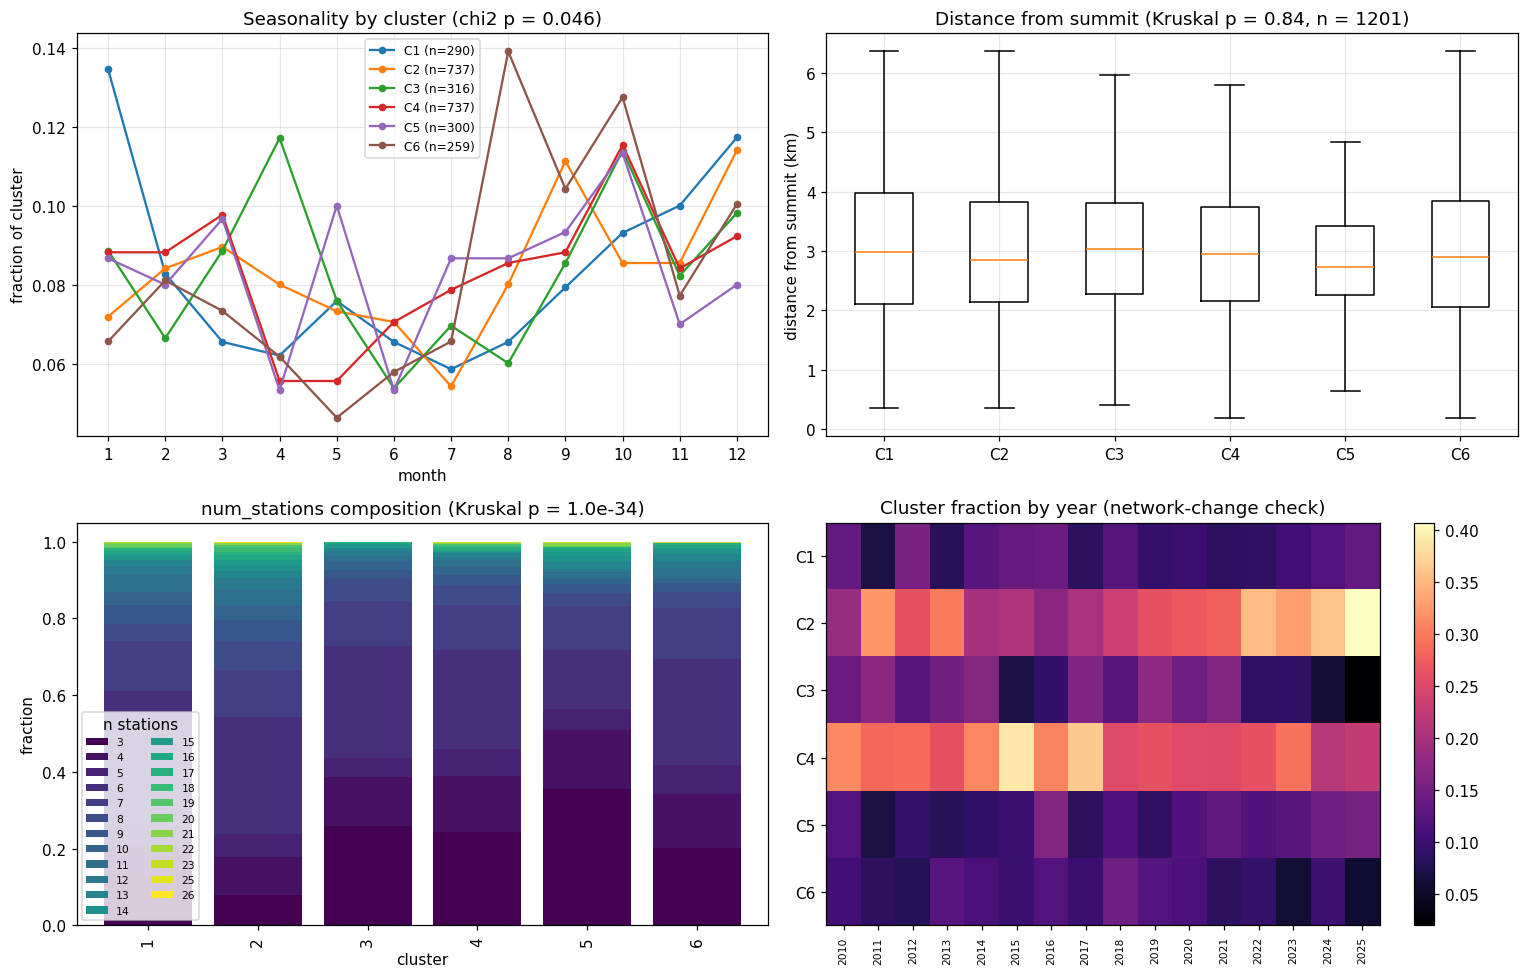

In [14]:
ctn = ct.div(ct.sum(1), axis=0)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0,0]
for cl in sorted(df.cluster.unique()):
    ax.plot(ctn.columns, ctn.loc[cl], marker="o", ms=4, label=f"C{cl} (n={ct.loc[cl].sum()})")
ax.set_xticks(range(1,13)); ax.set_xlabel("month"); ax.set_ylabel("fraction of cluster")
ax.set_title(f"Seasonality by cluster (chi2 p = {p_month:.3f})"); ax.legend(fontsize=8); ax.grid(alpha=.3)

ax = axes[0,1]
ax.boxplot([loc[loc.cluster==cl].dist_from_summit_km.values for cl in sorted(loc.cluster.unique())],
           tick_labels=[f"C{cl}" for cl in sorted(loc.cluster.unique())], showfliers=False)
ax.set_ylabel("distance from summit (km)")
ax.set_title(f"Distance from summit (Kruskal p = {p_dist:.2f}, n = {len(loc)})"); ax.grid(alpha=.3)

ax = axes[1,0]
pd.crosstab(df.cluster, df.num_stations, normalize="index").plot(
    kind="bar", stacked=True, ax=ax, colormap="viridis", width=.8)
ax.set_ylabel("fraction"); ax.set_xlabel("cluster")
ax.set_title(f"num_stations composition (Kruskal p = {p_sta:.1e})")
ax.legend(title="n stations", fontsize=7, ncol=2)

ax = axes[1,1]
yr = pd.crosstab(df.cluster, df.year, normalize="columns")
im = ax.imshow(yr.values, aspect="auto", cmap="magma")
ax.set_yticks(range(len(yr.index))); ax.set_yticklabels([f"C{c}" for c in yr.index])
ax.set_xticks(range(len(yr.columns))); ax.set_xticklabels(yr.columns, rotation=90, fontsize=7)
ax.set_title("Cluster fraction by year (network-change check)"); plt.colorbar(im, ax=ax)

plt.tight_layout(); plt.savefig(f"{OUT}/cluster_composition_k{K}.png", dpi=140); plt.show()

### External validation results — largely negative

| test | result | reading |
|---|---|---|
| month × cluster | χ² = 73.8, dof = 55, **p = 0.046** | marginal; at n=2,639 and 55 dof this is close to noise |
| distance from summit | H = 2.1, **p = 0.84** | **no separation at all** (medians 2.73–3.04 km) |
| num_stations | H = 169.4, **p = 1e-34** | strongly significant, but a *recording* property |

**Seasonality does not reproduce the Allstadt & Malone (2014) distinction.** Five of six clusters
share a median month of 7.0, and peak months scatter (Jan, Dec, Apr, Oct, Oct, Aug) in a way
consistent with noise in a broadly flat distribution. If the clusters corresponded to
seasonally-driven source types (e.g. snow/ice avalanches vs rockfall), a much sharper split
would be expected.

**Distance from summit is completely null** — the strongest negative result here. Cluster
medians span 2.73–3.04 km with p = 0.84.

**The one strong signal, `num_stations`, is a detectability property, not a source property.**
It is driven mainly by C5 (median 4 stations vs 6 elsewhere; only 26% located) — the cluster
that looks most like a low-SNR group rather than a physical class.

In [15]:
# How much of the partition is explained by recording conditions alone?
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

feats = ["num_stations","mean_prob","mean_max","peak_prob","frac_su","year","month"]
acc = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=0),
                      df[feats].values, lab, cv=5).mean()
base = np.bincount(lab).max()/len(lab)
print(f"predicting cluster from METADATA ONLY : {acc:.3f} (majority baseline {base:.3f}, lift {acc-base:+.3f})")

print("\nSpearman rho, principal components vs metadata:")
out = pd.DataFrame({c: [spearmanr(Z[:, i], df[c].values).statistic for i in range(4)]
                    for c in ["num_stations","mean_prob","peak_prob","year"]},
                   index=[f"PC{i+1}" for i in range(4)])
print(out.round(3).to_string())

predicting cluster from METADATA ONLY : 0.315 (majority baseline 0.279, lift +0.035)

Spearman rho, principal components vs metadata:
     num_stations  mean_prob  peak_prob   year
PC1        -0.255     -0.284     -0.221 -0.134
PC2        -0.023      0.103      0.701  0.079
PC3        -0.087     -0.066      0.105  0.143
PC4         0.158      0.195      0.335  0.032


**The clusters are not simply metadata artifacts.** Catalog metadata alone predicts cluster
membership at 31.5% vs a 27.9% majority baseline — a lift of only +3.5 points. So the partition
does encode waveform information beyond recording conditions.

One caveat is worth recording: **PC2 (21.8% of total variance) correlates at ρ = 0.70 with
`peak_prob`** — i.e. roughly a fifth of the embedding's variance is an axis of *classifier
confidence* rather than source character. That is expected for a classifier penultimate layer,
but it is variance that clustering will happily latch onto without it meaning anything physical.

So the position is: the clusters reflect something real in waveform space, but that something
is unstable under resampling and does not align with any physical axis available for validation.

## Conclusions

**1. The feature space needs revisiting before within-`su` clustering will work.** This is the
main finding. The 128-d QuakeXNet embedding collapses to ~3.7 effective dimensions on the
`su`-only subset (PC1 = 43.9%, 5 dims = 90% of variance). QuakeXNet was trained to separate
*classes*; within a single class it retains little structure, and ~22% of what remains is a
classifier-confidence axis (PC2 vs `peak_prob`, ρ = 0.70).

**2. PCA-10d is the right reduction** (trustworthiness 1.000 vs UMAP's 0.987, deterministic,
metric-faithful for Ward). PCA-5d would be defensible and cleaner. UMAP offers nothing here.

**3. Ward is the only usable linkage.** Average linkage's superior silhouette comes from
isolating 12 outliers; complete is dominated by Ward throughout.

**4. There is no defensible cut point in the strong sense.** Silhouette declines monotonically
from *k*=2 with no elbow; all values <0.25. Structure above a covariance-matched null peaks at
*k*=6 (z ≈ 8.7), but **bootstrap stability is ≈0.37 ARI at every *k*** — the partition does not
survive resampling. *k*=6 is the least-arbitrary choice available, not a well-supported one.

**5. External validation is largely negative.** Distance from summit is null (p = 0.84);
seasonality is marginal (p = 0.046) and does not reproduce Allstadt & Malone (2014);
the one strong signal (`num_stations`, p = 1e-34) is a detectability property.

### Recommendation

**Do not interpret the *k*=6 labels as surface-event types.** They are saved in
`su_cluster_assignments_k6.csv` as a provisional grouping, and are reasonable as a *sampling
frame* — e.g. for drawing a stratified subset for the waveform cross-correlation follow-up —
but not as a result.

Before re-running this analysis, consider:
- **Features from an earlier QuakeXNet layer**, or a model not trained for class discrimination
  (self-supervised / autoencoder), to avoid the single-class collapse.
- **Explicit physical features** — duration, spectral centroid/bandwidth, envelope shape,
  rise-time — which are what Allstadt & Malone (2014) discriminate on and are absent from
  a classifier embedding.
- **Restricting to the well-recorded subset** (≥5 stations) to reduce the SNR gradient that
  currently drives C5.
- **Regressing out the `peak_prob` axis** before clustering.

### TODO — follow-up notebook (deliberately not done here)

**Waveform cross-correlation validation (Allstadt & Malone 2014-style).** Take a small
stratified subset of events within and across the *k*=6 clusters and compare them by direct
waveform cross-correlation rather than embedding distance. Given the results above this is now
the decisive test: if within-cluster CC is not materially higher than across-cluster CC, the
embedding-based grouping carries no source information and the feature space should be replaced
outright before any further clustering work.